# Hierarchical Customer Segmentation

## Goal

The goal of this notebook is to use hierarchical clustering to segment mall customers based on income, spending behaviour, and demographic features.

Hierarchical clustering is useful because it does not only assign cluster labels. It also shows how observations are connected through a tree-like structure called a dendrogram.

This notebook explores:

- Customer segmentation
- Feature scaling
- Distance-based clustering
- Linkage methods
- Dendrogram interpretation
- Agglomerative clustering
- Cluster evaluation
- Cluster profiling
- Comparison with K-Means

The main objective is to understand how hierarchical clustering forms customer groups and how those groups can be interpreted for business decisions.

In [1]:
import os
import warnings

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)

c:\Users\ADMIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.4.0) or chardet (7.4.3)/charset_normalizer (3.4.2) doesn't match a supported version!
  warnings.warn(


## Setup

This notebook uses SciPy and scikit-learn for hierarchical clustering.

SciPy is used to create linkage matrices and dendrograms. Scikit-learn is used for preprocessing, clustering, evaluation metrics, PCA visualization, and K-Means comparison.

Because hierarchical clustering depends on distances between observations, feature scaling is especially important.

In [2]:
path = kagglehub.dataset_download("vjchoudhary7/customer-segmentation-tutorial-in-python")

print("Dataset downloaded to:", path)
print("Files:")
print(os.listdir(path))

Dataset downloaded to: C:\Users\ADMIN\.cache\kagglehub\datasets\vjchoudhary7\customer-segmentation-tutorial-in-python\versions\1
Files:
['Mall_Customers.csv']


In [3]:
csv_files = [file for file in os.listdir(path) if file.endswith(".csv")]
csv_files

['Mall_Customers.csv']

In [4]:
csv_path = os.path.join(path, csv_files[0])
df = pd.read_csv(csv_path)

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


This notebook uses the Mall Customer Segmentation dataset from Kaggle.

Each row represents one mall customer. The dataset includes customer demographic and spending-related features.

The main columns are expected to include:

- CustomerID
- Gender
- Age
- Annual Income
- Spending Score

The task is unsupervised learning because there is no target label. The goal is to discover natural customer segments from the available features.

In [5]:
print("Shape:", df.shape)
df.info()

Shape: (200, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [6]:
df.describe(include="all")

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200,200.000000,200.000000,200.000000
unique,NaN,2,NaN,NaN,NaN
top,NaN,Female,NaN,NaN,NaN
freq,NaN,112,NaN,NaN,NaN
mean,100.500000,NaN,38.850000,60.560000,50.200000
std,57.879185,NaN,13.969007,26.264721,25.823522
min,1.000000,NaN,18.000000,15.000000,1.000000
25%,50.750000,NaN,28.750000,41.500000,34.750000
50%,100.500000,NaN,36.000000,61.500000,50.000000
75%,150.250000,NaN,49.000000,78.000000,73.000000


## Initial Data Inspection

The dataset contains 200 customers and 5 columns.

The available features are:

- `CustomerID`
- `Gender`
- `Age`
- `Annual Income (k$)`
- `Spending Score (1-100)`

There are no missing values in the dataset.

The average customer age is 38.85 years. The average annual income is 60.56k, and the average spending score is 50.20.

The dataset is suitable for hierarchical clustering because it is small enough to visualize with dendrograms and contains meaningful customer attributes for segmentation.

In [7]:
df_clean = df.copy()

df_clean.columns = (
    df_clean.columns
    .str.strip()
    .str.replace(" ", "_")
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
    .str.replace("$", "Dollars", regex=False)
    .str.replace("-", "_", regex=False)
)

df_clean.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual_Income_kDollars',
       'Spending_Score_1_100'],
      dtype='object')

In [8]:
numeric_cols = df_clean.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df_clean.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

Numeric columns: ['CustomerID', 'Age', 'Annual_Income_kDollars', 'Spending_Score_1_100']
Categorical columns: ['Gender']


In [11]:
id_cols = ['CustomerID']
feature_df = df_clean.drop(columns=id_cols)
feature_df.head()

,Gender,Age,Annual_Income_kDollars,Spending_Score_1_100
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


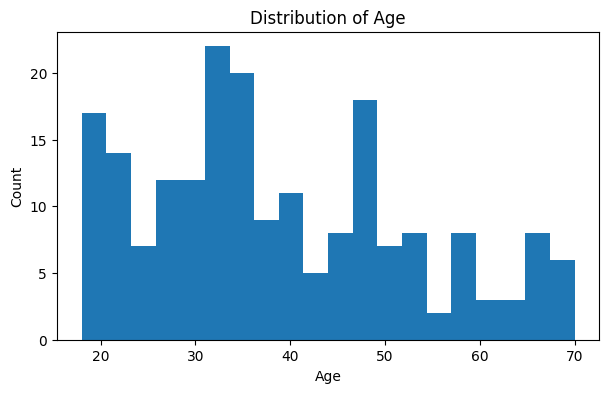

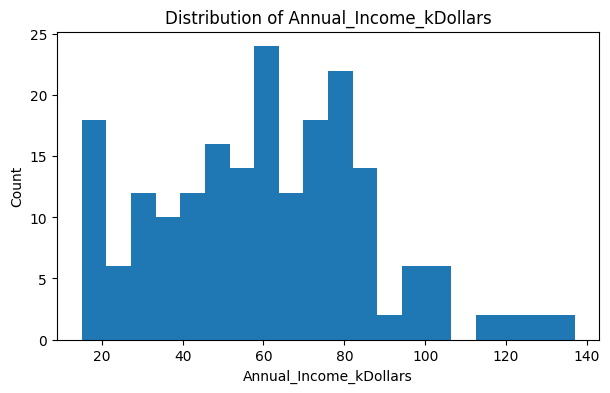

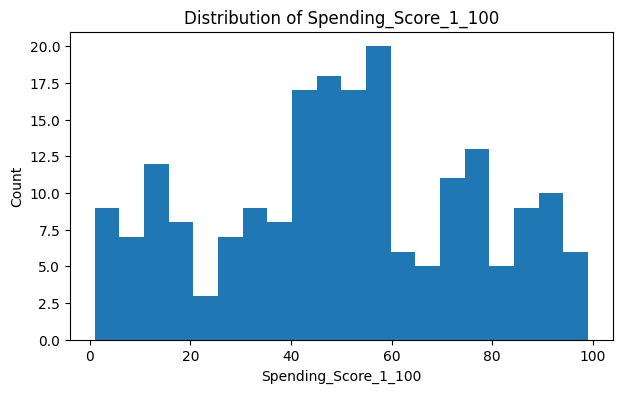

In [12]:
numeric_features = feature_df.select_dtypes(include=["int64", "float64"]).columns.tolist()

for col in numeric_features:
    plt.figure(figsize=(7, 4))
    plt.hist(feature_df[col], bins=20)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

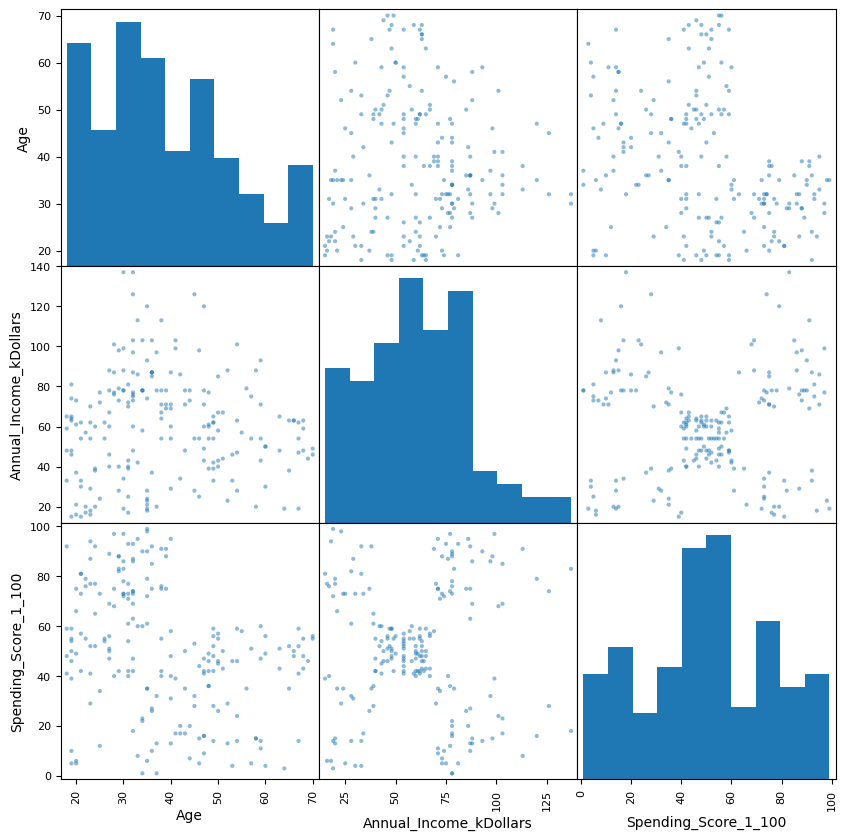

In [13]:
pd.plotting.scatter_matrix(
    feature_df[numeric_features],
    figsize=(10, 10),
    diagonal="hist"
)
plt.show()

## Exploratory Data Analysis

The numerical distributions help show the range and shape of each customer feature.

Scatter plots are useful for checking whether natural groups appear in pairs of features.

For customer segmentation, `Annual Income` and `Spending Score` are especially important because they describe purchasing power and spending behaviour.

Hierarchical clustering can use all selected features, but visual inspection helps understand whether the clusters are likely to be meaningful.

In [15]:
numeric_features = feature_df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = feature_df.select_dtypes(include=["object", "category"]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first", sparse_output=False), categorical_features)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

X_processed = preprocessor.fit_transform(feature_df)

feature_names = preprocessor.get_feature_names_out()

X_processed_df = pd.DataFrame(
    X_processed,
    columns=feature_names
)

X_processed_df.head()

,Age,Annual_Income_kDollars,Spending_Score_1_100,Gender_Male
0,-1.424569,-1.738999,-0.434801,1.0
1,-1.281035,-1.738999,1.195704,1.0
2,-1.352802,-1.700830,-1.715913,0.0
3,-1.137502,-1.700830,1.040418,0.0
4,-0.563369,-1.662660,-0.395980,0.0


## Preprocessing

The dataset contains numerical and categorical features.

Numerical features are standardized so that each feature has a mean of 0 and a standard deviation of 1.

Categorical features are one-hot encoded so they can be used in distance calculations.

Scaling is essential for hierarchical clustering because the algorithm uses distances between customers. Without scaling, features with larger numerical ranges would dominate the clustering result.

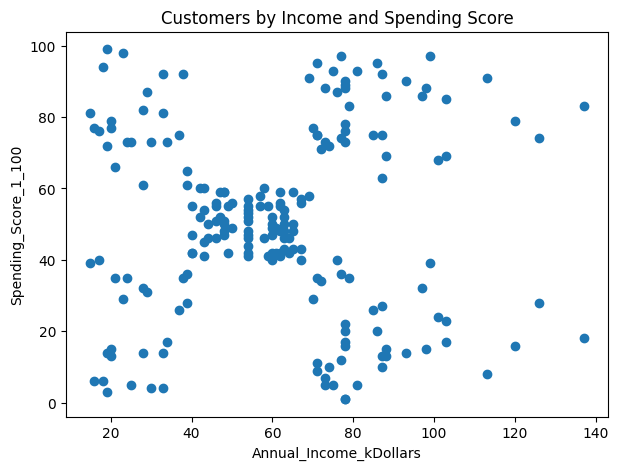

In [16]:
income_col = [col for col in df_clean.columns if "income" in col.lower()][0]
spending_col = [col for col in df_clean.columns if "spending" in col.lower()][0]

income_col, spending_col
X_2d = df_clean[[income_col, spending_col]].copy()

scaler_2d = StandardScaler()
X_2d_scaled = scaler_2d.fit_transform(X_2d)

plt.figure(figsize=(7, 5))
plt.scatter(X_2d[income_col], X_2d[spending_col])
plt.title("Customers by Income and Spending Score")
plt.xlabel(income_col)
plt.ylabel(spending_col)
plt.show()

## Focused 2D Clustering View

The income and spending score features are used to create a simple two-dimensional customer segmentation view.

This view is useful because the clusters can be plotted directly and interpreted easily.

Although the full clustering model can use more features, the 2D income-spending view is a good starting point for understanding hierarchical clustering.

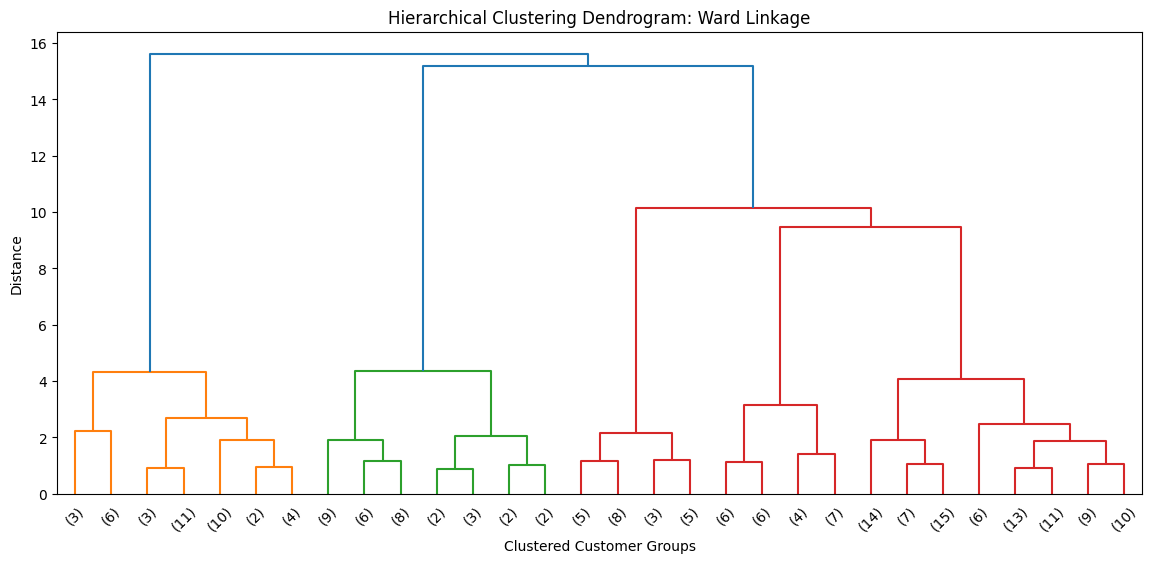

In [17]:
linkage_matrix = linkage(X_2d_scaled, method="ward")

plt.figure(figsize=(14, 6))
dendrogram(
    linkage_matrix,
    truncate_mode="lastp",
    p=30,
    leaf_rotation=45,
    leaf_font_size=10
)
plt.title("Hierarchical Clustering Dendrogram: Ward Linkage")
plt.xlabel("Clustered Customer Groups")
plt.ylabel("Distance")
plt.show()

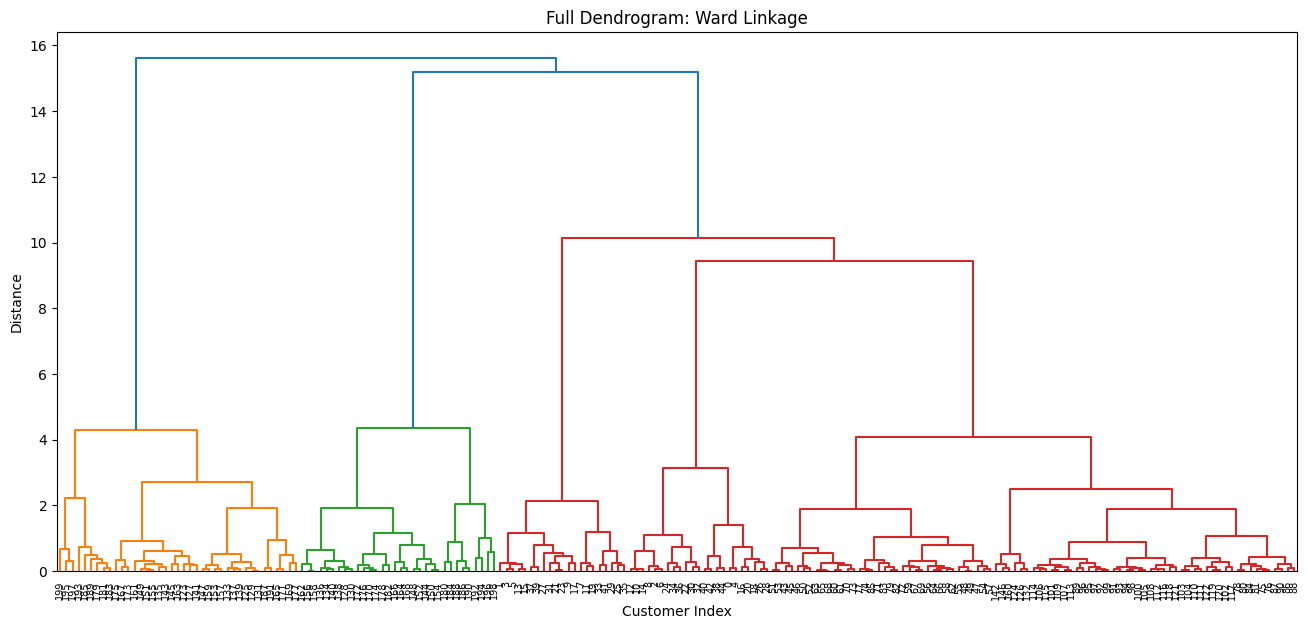

In [18]:
plt.figure(figsize=(16, 7))
dendrogram(
    linkage_matrix,
    leaf_rotation=90,
    leaf_font_size=7
)
plt.title("Full Dendrogram: Ward Linkage")
plt.xlabel("Customer Index")
plt.ylabel("Distance")
plt.show()

## Dendrogram Interpretation

A dendrogram shows how observations are merged step by step.

Each leaf represents an individual customer. Branches show which customers or groups are merged together.

The height of a merge represents the distance between the clusters being joined.

Large vertical jumps in the dendrogram suggest that very different groups are being merged. These jumps can help choose a reasonable number of clusters.

Ward linkage is used because it tends to create compact clusters by minimizing within-cluster variance.

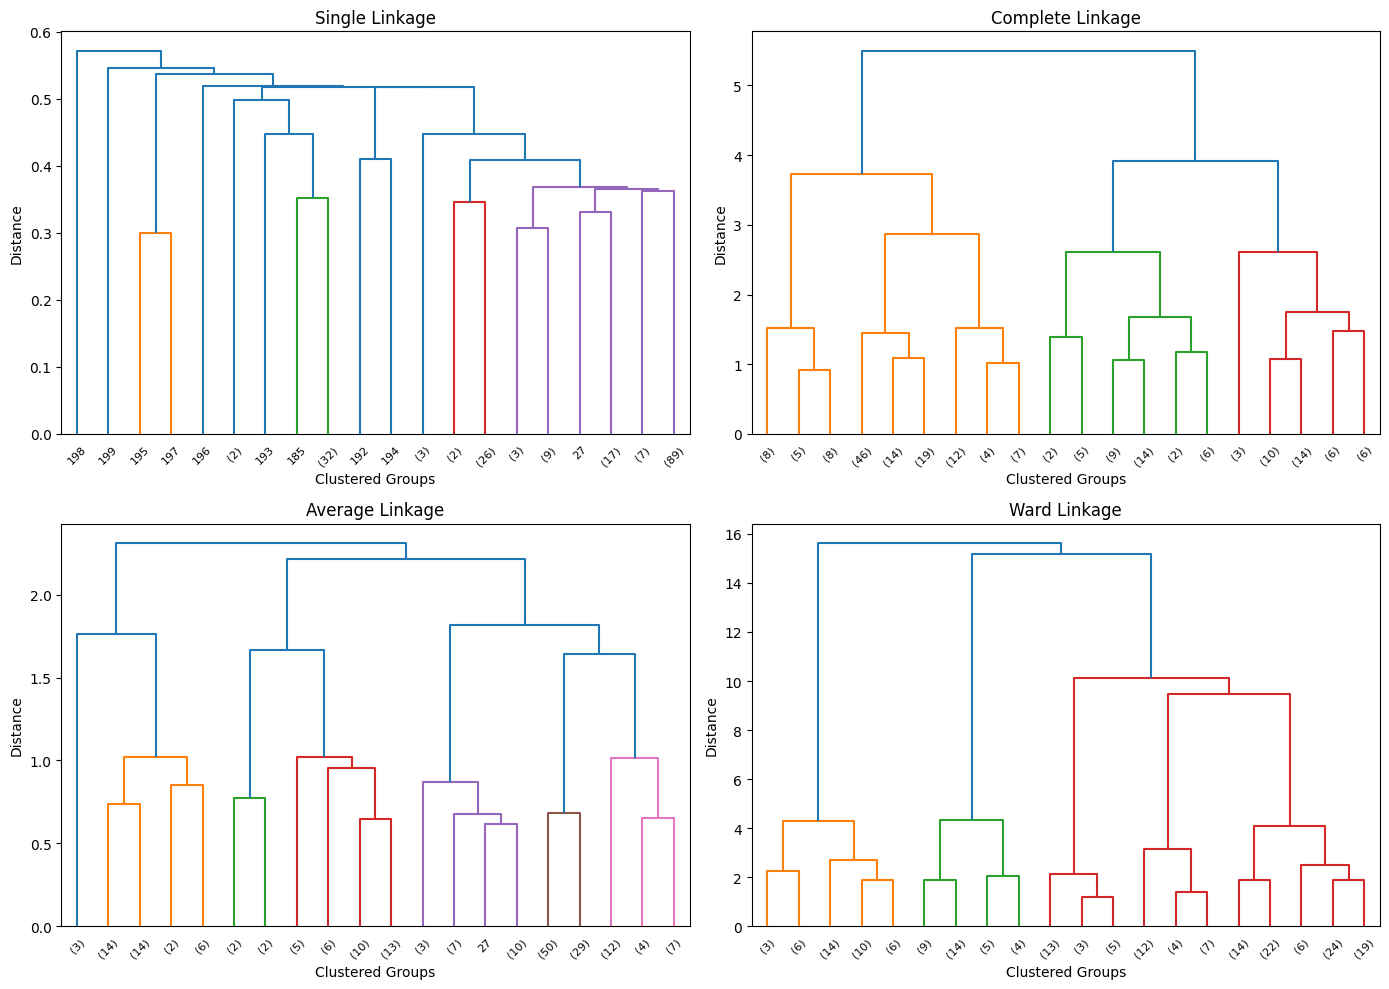

In [19]:
linkage_methods = ["single", "complete", "average", "ward"]

plt.figure(figsize=(14, 10))

for i, method in enumerate(linkage_methods, start=1):
    Z = linkage(X_2d_scaled, method=method)
    
    plt.subplot(2, 2, i)
    dendrogram(
        Z,
        truncate_mode="lastp",
        p=20,
        leaf_rotation=45,
        leaf_font_size=8
    )
    plt.title(f"{method.title()} Linkage")
    plt.xlabel("Clustered Groups")
    plt.ylabel("Distance")

plt.tight_layout()
plt.show()

## Linkage Method Comparison

Hierarchical clustering requires a linkage method, which controls how distances between clusters are calculated.

Common linkage methods include:

- Single linkage: distance between the closest points in two clusters
- Complete linkage: distance between the farthest points in two clusters
- Average linkage: average pairwise distance between points in two clusters
- Ward linkage: merge that minimizes within-cluster variance

Single linkage can create long chain-like clusters. Complete and average linkage are often more balanced. Ward linkage usually creates compact and interpretable clusters for numerical data.

Comparing linkage methods helps show that hierarchical clustering is sensitive to how cluster distance is defined.

In [20]:
cluster_eval_rows = []

for k in range(2, 11):
    model = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward"
    )
    
    labels = model.fit_predict(X_2d_scaled)
    
    cluster_eval_rows.append({
        "k": k,
        "silhouette_score": silhouette_score(X_2d_scaled, labels),
        "davies_bouldin_score": davies_bouldin_score(X_2d_scaled, labels),
        "calinski_harabasz_score": calinski_harabasz_score(X_2d_scaled, labels)
    })

cluster_eval_df = pd.DataFrame(cluster_eval_rows)
cluster_eval_df

,k,silhouette_score,davies_bouldin_score,calinski_harabasz_score
0,2,0.384234,0.854356,86.961556
1,3,0.461048,0.707287,143.779562
2,4,0.492551,0.670718,169.679831
3,5,0.553809,0.577862,244.410326
4,6,0.538676,0.644868,233.308806
5,7,0.519795,0.713283,237.258506
6,8,0.430862,0.777741,250.588294
7,9,0.437690,0.776487,252.929359
8,10,0.433901,0.766997,252.517220


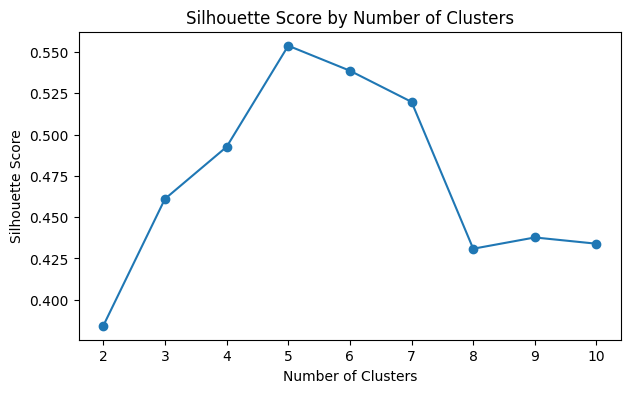

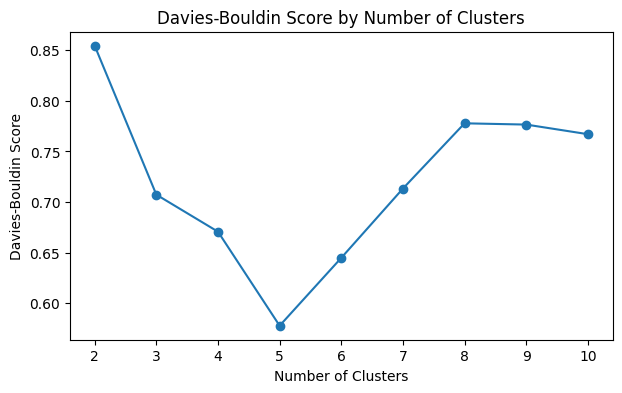

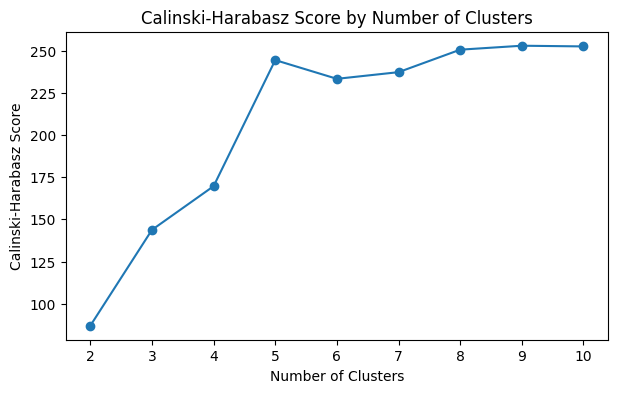

In [21]:
plt.figure(figsize=(7, 4))
plt.plot(cluster_eval_df["k"], cluster_eval_df["silhouette_score"], marker="o")
plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(cluster_eval_df["k"], cluster_eval_df["davies_bouldin_score"], marker="o")
plt.title("Davies-Bouldin Score by Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Davies-Bouldin Score")
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(cluster_eval_df["k"], cluster_eval_df["calinski_harabasz_score"], marker="o")
plt.title("Calinski-Harabasz Score by Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Calinski-Harabasz Score")
plt.show()

## Choosing the Number of Clusters

The dendrogram gives a visual method for choosing the number of clusters, but evaluation metrics can also help.

This notebook compares several values of `k` using:

- Silhouette score: higher is better
- Davies-Bouldin score: lower is better
- Calinski-Harabasz score: higher is better

For the 2D income-spending clustering model, the best value by silhouette score was `k = 5`, with a silhouette score of 0.5538.

The best value by Davies-Bouldin score was also `k = 5`, with a score of 0.5779.

The best value by Calinski-Harabasz score was `k = 9`, with a score of 252.9294.

Although Calinski-Harabasz slightly preferred more clusters, both the silhouette score and Davies-Bouldin score supported `k = 5`. This also matches the common visual structure in the income-spending customer segmentation plot.

Therefore, the final 2D hierarchical clustering model uses 5 clusters.

In [22]:
FINAL_K = 5

hier_model = AgglomerativeClustering(
    n_clusters=FINAL_K,
    linkage="ward"
)

df_clean["hier_cluster"] = hier_model.fit_predict(X_2d_scaled)

df_clean["hier_cluster"].value_counts().sort_index()

hier_cluster
0    32
1    39
2    85
3    21
4    23
Name: count, dtype: int64

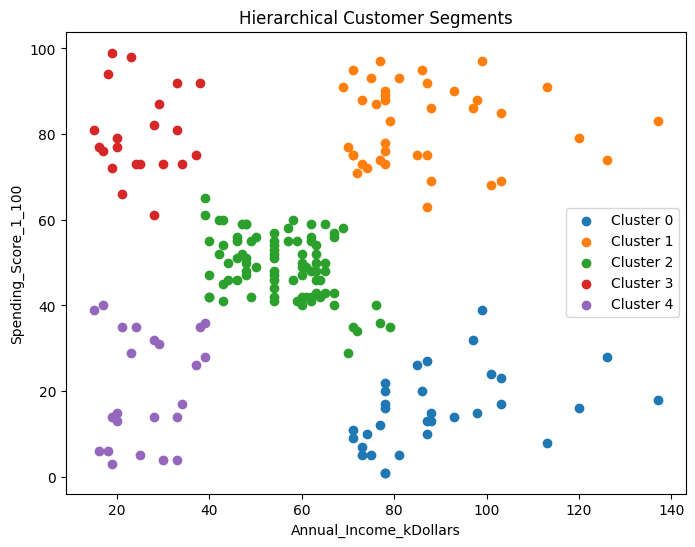

In [23]:
plt.figure(figsize=(8, 6))

for cluster_id in sorted(df_clean["hier_cluster"].unique()):
    cluster_data = df_clean[df_clean["hier_cluster"] == cluster_id]
    plt.scatter(
        cluster_data[income_col],
        cluster_data[spending_col],
        label=f"Cluster {cluster_id}"
    )

plt.title("Hierarchical Customer Segments")
plt.xlabel(income_col)
plt.ylabel(spending_col)
plt.legend()
plt.show()

## Final Hierarchical Clustering Model

The final hierarchical clustering model is fitted using Ward linkage and 5 clusters.

The clustering is based on annual income and spending score, which makes the customer segments easy to visualize and interpret.

The final cluster sizes are:

- Cluster 0: 32 customers
- Cluster 1: 39 customers
- Cluster 2: 85 customers
- Cluster 3: 21 customers
- Cluster 4: 23 customers

The scatter plot shows clear customer groups based on income and spending behaviour.

This 2D version is useful because the customer segments can be interpreted directly in business terms, such as high-income high-spending customers or low-income low-spending customers.

In [24]:
cluster_profile = (
    df_clean
    .groupby("hier_cluster")
    .agg(
        customers=("hier_cluster", "count"),
        avg_age=("Age", "mean"),
        avg_income=(income_col, "mean"),
        avg_spending=(spending_col, "mean")
    )
    .reset_index()
)

In [25]:
if "Gender" in df_clean.columns:
    gender_profile = pd.crosstab(
        df_clean["hier_cluster"],
        df_clean["Gender"],
        normalize="index"
    )
    display(gender_profile)

Gender,Female,Male
hier_cluster,,
0,0.437500,0.562500
1,0.538462,0.461538
2,0.600000,0.400000
3,0.571429,0.428571
4,0.608696,0.391304


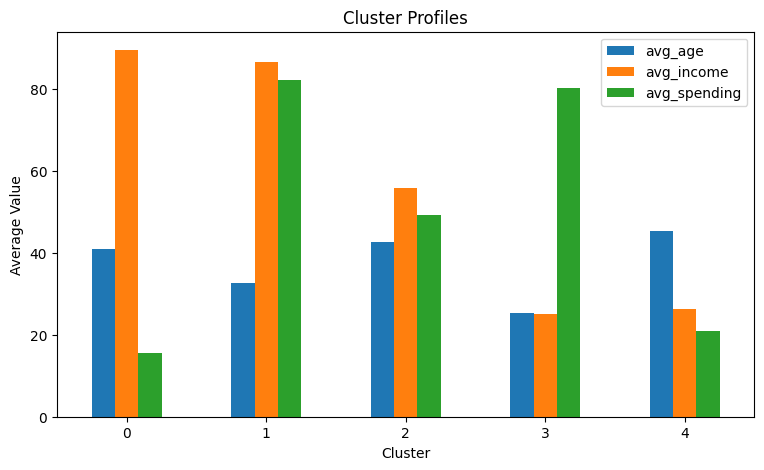

In [26]:
profile_plot = cluster_profile.set_index("hier_cluster")[["avg_age", "avg_income", "avg_spending"]]

profile_plot.plot(kind="bar", figsize=(9, 5))
plt.title("Cluster Profiles")
plt.xlabel("Cluster")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.show()

In [27]:
def name_segment(row):
    income = row[income_col]
    spending = row[spending_col]
    
    if income >= df_clean[income_col].median() and spending >= df_clean[spending_col].median():
        return "High Income / High Spending"
    elif income >= df_clean[income_col].median() and spending < df_clean[spending_col].median():
        return "High Income / Low Spending"
    elif income < df_clean[income_col].median() and spending >= df_clean[spending_col].median():
        return "Low Income / High Spending"
    else:
        return "Low Income / Low Spending"

segment_names = (
    df_clean
    .groupby("hier_cluster")
    .apply(lambda group: name_segment(group[[income_col, spending_col]].mean()))
    .to_dict()
)

segment_names

{0: 'High Income / Low Spending',
 1: 'High Income / High Spending',
 2: 'Low Income / Low Spending',
 3: 'Low Income / High Spending',
 4: 'Low Income / Low Spending'}

In [28]:
df_clean["segment_name"] = df_clean["hier_cluster"].map(segment_names)

df_clean[["hier_cluster", "segment_name", income_col, spending_col]].head()

,hier_cluster,segment_name,Annual_Income_kDollars,Spending_Score_1_100
0,4,Low Income / Low Spending,15,39
1,3,Low Income / High Spending,15,81
2,4,Low Income / Low Spending,16,6
3,3,Low Income / High Spending,16,77
4,4,Low Income / Low Spending,17,40


In [29]:
df_clean["segment_name"].value_counts()

segment_name
Low Income / Low Spending      108
High Income / High Spending     39
High Income / Low Spending      32
Low Income / High Spending      21
Name: count, dtype: int64

## Segment Naming

Cluster labels are converted into readable segment names.

This makes the clustering result easier to interpret for a business audience.

Instead of saying "Cluster 0" or "Cluster 1", the notebook describes customers using income and spending behaviour, such as:

- High Income / High Spending
- High Income / Low Spending
- Low Income / High Spending
- Low Income / Low Spending

Readable labels make customer segmentation more useful for communication and decision-making.

In [30]:
kmeans = KMeans(
    n_clusters=FINAL_K,
    random_state=42,
    n_init=10
)

df_clean["kmeans_cluster"] = kmeans.fit_predict(X_2d_scaled)

kmeans_silhouette = silhouette_score(X_2d_scaled, df_clean["kmeans_cluster"])
hier_silhouette = silhouette_score(X_2d_scaled, df_clean["hier_cluster"])

print("Hierarchical silhouette:", hier_silhouette)
print("K-Means silhouette:", kmeans_silhouette)

Hierarchical silhouette: 0.5538089226688662
K-Means silhouette: 0.5546571631111091


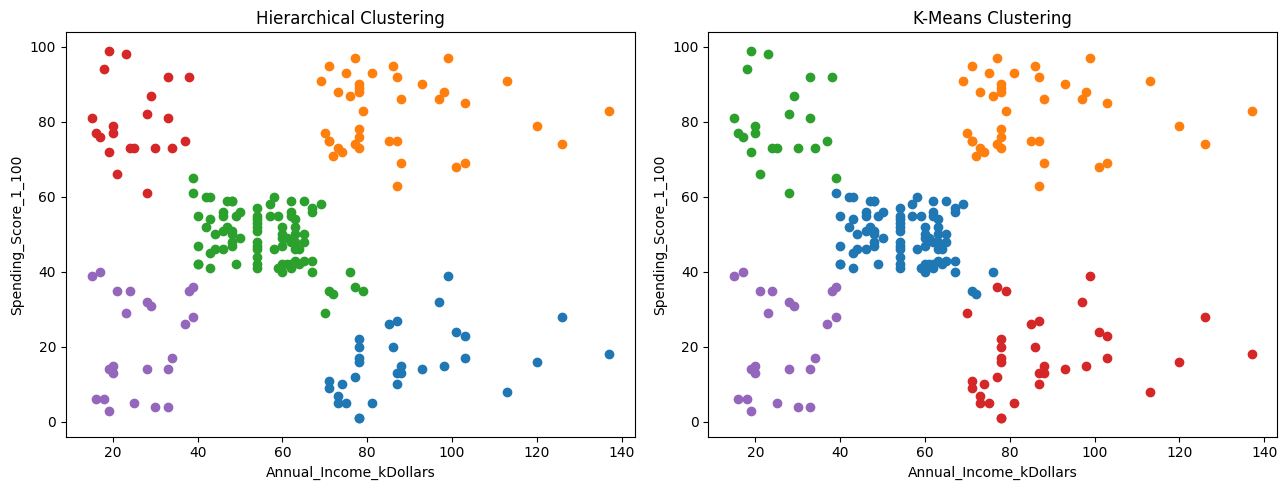

In [31]:
plt.figure(figsize=(13, 5))

plt.subplot(1, 2, 1)
for cluster_id in sorted(df_clean["hier_cluster"].unique()):
    cluster_data = df_clean[df_clean["hier_cluster"] == cluster_id]
    plt.scatter(cluster_data[income_col], cluster_data[spending_col], label=f"Cluster {cluster_id}")
plt.title("Hierarchical Clustering")
plt.xlabel(income_col)
plt.ylabel(spending_col)

plt.subplot(1, 2, 2)
for cluster_id in sorted(df_clean["kmeans_cluster"].unique()):
    cluster_data = df_clean[df_clean["kmeans_cluster"] == cluster_id]
    plt.scatter(cluster_data[income_col], cluster_data[spending_col], label=f"Cluster {cluster_id}")
plt.title("K-Means Clustering")
plt.xlabel(income_col)
plt.ylabel(spending_col)

plt.tight_layout()
plt.show()

## Comparison with K-Means

Hierarchical clustering and K-Means are both unsupervised clustering algorithms, but they work differently.

K-Means directly partitions the data into `k` clusters by optimizing cluster centroids.

Hierarchical clustering builds a tree of nested clusters and can be visualized using a dendrogram.

In this notebook, hierarchical clustering achieved a silhouette score of 0.5538, while K-Means achieved a silhouette score of 0.5547.

The two scores are almost identical, with K-Means performing only slightly higher.

The visual comparison shows that both methods produce very similar customer segments in the income-spending space.

This suggests that the customer groups are naturally well separated in two dimensions. Hierarchical clustering is still useful because the dendrogram provides extra insight into how customers and clusters are merged step by step.

In [32]:
full_cluster_eval_rows = []

for k in range(2, 11):
    model = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward"
    )
    
    labels = model.fit_predict(X_processed_df)
    
    full_cluster_eval_rows.append({
        "k": k,
        "silhouette_score": silhouette_score(X_processed_df, labels),
        "davies_bouldin_score": davies_bouldin_score(X_processed_df, labels),
        "calinski_harabasz_score": calinski_harabasz_score(X_processed_df, labels)
    })

full_cluster_eval_df = pd.DataFrame(full_cluster_eval_rows)
full_cluster_eval_df

,k,silhouette_score,davies_bouldin_score,calinski_harabasz_score
0,2,0.292304,1.391227,90.894319
1,3,0.309725,1.180790,83.445022
2,4,0.329905,1.114677,91.365736
3,5,0.347756,1.068573,91.277802
4,6,0.350444,1.008615,95.257661
5,7,0.315405,1.071074,89.605500
6,8,0.325167,1.039632,85.087954
7,9,0.323259,0.993352,82.493435
8,10,0.324601,1.054759,80.167700


In [33]:
FULL_FINAL_K = full_cluster_eval_df.sort_values("silhouette_score", ascending=False).iloc[0]["k"]
FULL_FINAL_K = int(FULL_FINAL_K)

full_hier_model = AgglomerativeClustering(
    n_clusters=FULL_FINAL_K,
    linkage="ward"
)

df_clean["full_hier_cluster"] = full_hier_model.fit_predict(X_processed_df)

print("Selected full-feature k:", FULL_FINAL_K)
df_clean["full_hier_cluster"].value_counts().sort_index()

Selected full-feature k: 6


full_hier_cluster
0    50
1    20
2    33
3    39
4    35
5    23
Name: count, dtype: int64

PCA explained variance: 0.7176959022847651


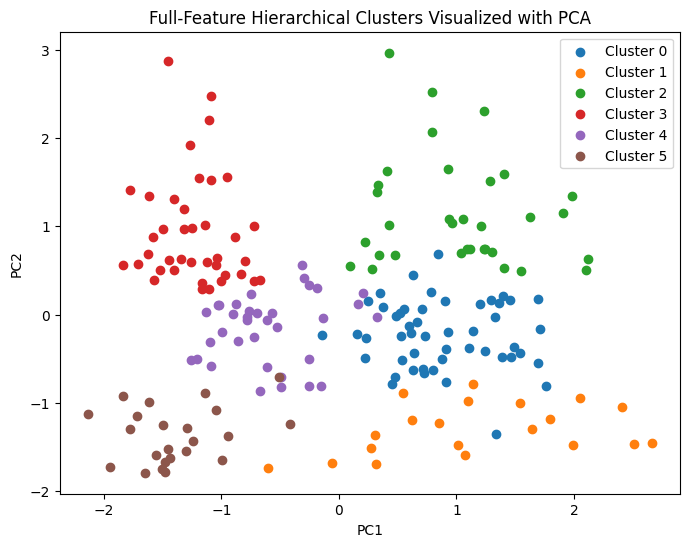

In [34]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_processed_df)

print("PCA explained variance:", pca.explained_variance_ratio_.sum())

plt.figure(figsize=(8, 6))

for cluster_id in sorted(df_clean["full_hier_cluster"].unique()):
    mask = df_clean["full_hier_cluster"] == cluster_id
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=f"Cluster {cluster_id}"
    )

plt.title("Full-Feature Hierarchical Clusters Visualized with PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

In [35]:
full_cluster_profile = (
    df_clean
    .groupby("full_hier_cluster")
    .agg(
        customers=("full_hier_cluster", "count"),
        avg_age=("Age", "mean"),
        avg_income=(income_col, "mean"),
        avg_spending=(spending_col, "mean")
    )
    .reset_index()
)

full_cluster_profile

,full_hier_cluster,customers,avg_age,avg_income,avg_spending
0,0,50,54.960000,53.620000,48.240000
1,1,20,43.750000,25.250000,19.050000
2,2,33,41.454545,89.090909,16.181818
3,3,39,32.692308,86.538462,82.128205
4,4,35,26.142857,57.228571,48.685714
5,5,23,25.608696,26.434783,78.521739


## Full-Feature Hierarchical Clustering

The first clustering model used only annual income and spending score because it is easy to visualize.

This section extends the analysis by using all available customer features after preprocessing, including age, gender, annual income, and spending score.

For the full-feature model, the best silhouette score was achieved with `k = 6`, with a silhouette score of 0.3504.

The selected full-feature clustering model therefore uses 6 clusters.

The PCA visualization explains approximately 71.77% of the variance using the first two principal components. This means the 2D PCA plot captures a useful amount of structure, but it is still only a simplified projection of the full feature space.

The full-feature cluster profile shows the following customer groups:

- Cluster 0: 50 customers, older average age, moderate income, moderate spending
- Cluster 1: 20 customers, lower income, low spending
- Cluster 2: 33 customers, high income, low spending
- Cluster 3: 39 customers, high income, high spending
- Cluster 4: 35 customers, younger customers with moderate income and moderate spending
- Cluster 5: 23 customers, young, lower income, high spending

Using more features creates richer customer segments because age and gender can influence the grouping. However, the result is less directly visual than the 2D income-spending model.

The full-feature clustering result should be interpreted mainly through the cluster profile rather than only the PCA plot.